# Snow Cover Prediction & Economic Impact — Steamboat Springs Prototype
### Masters Thesis in Applied Economics | Eva Benson

This notebook implements a two-stage machine learning pipeline using satellite remote sensing data to predict snowfall timing and depth at Steamboat Springs, Colorado. The ultimate goal is to connect snow predictions to economic output (GDP / value added) for the ski industry.

**Pipeline overview:**
1. Load first snowfall date rasters from Google Earth Engine (GEE)
2. Load terrain predictors (elevation, slope, aspect)
3. Train a linear regression to predict first snow timing
4. Load SNODAS snow depth data and train a depth model
5. Load 24 years of MODIS snow cover duration data
6. Build a year-level climate model with physically interpretable coefficients
7. Run scenario analysis: what happens to snow duration under warming?

---
## Section 1: Setup and Data Loading

### 1.1 Load First Snow Day-of-Year Rasters (Landsat 8, 2017–2022)

These rasters were exported from Google Earth Engine using Landsat 8 imagery. For each year and each 30m pixel, GEE computed the first autumn day (DOY 240–366) where the Normalized Difference Snow Index (NDSI) exceeded 0.4 — the standard threshold for snow cover classification.

**NDSI formula:** (Green − SWIR) / (Green + SWIR)  
**DOY 240** = late August | **DOY 366** = December 31  
**Why autumn window?** Restricting to DOY 240–366 prevents January snow (DOY ~1–60) from being falsely identified as "first snow" of the season.

Each exported file is a 512×512 GeoTIFF at ~30m resolution covering a 15×15km region centered on Steamboat Springs (−106.83°, 40.48°).

In [2]:
# ── Imports: all libraries used throughout this notebook ──────────────────
import numpy as np                          # numerical array operations
import rasterio                             # read/write GeoTIFF raster files
import pandas as pd                         # dataframe operations
from pathlib import Path                    # cross-platform file path handling
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from itertools import combinations
import matplotlib.pyplot as plt
from scipy.ndimage import zoom              # raster resampling
import gzip, tarfile                        # SNODAS file extraction
from datetime import date, timedelta
import urllib.request

# ── File paths ────────────────────────────────────────────────────────────
# data_dir:  6-year prototype data (Landsat, SNODAS, 6-year Daymet)
# full_dir:  24-year full model data (MODIS 2000–2023, Daymet 2000–2023)
data_dir = Path("/Users/evabenson/Files/thesis/snow_ml/gee")
full_dir  = Path("/Users/evabenson/Files/thesis/snow_ml/gee_full/steamboat_snow_full")

# ── Study years ───────────────────────────────────────────────────────────
years      = [2017, 2018, 2019, 2020, 2021, 2022]   # Landsat prototype years
years_full = list(range(2000, 2024))                  # Full 24-year MODIS record

# ── Load first snow DOY rasters (one 512x512 array per year) ──────────────
# snow_stack shape after loading: (6, 512, 512)
# Indexing: snow_stack[0] = 2017, snow_stack[1] = 2018, etc.
snow_stack = []

for year in years:
    path = data_dir / f"firstsnow_{year}.tif"

    if not path.exists():
        print(f"WARNING: {path.name} not found, skipping.")
        continue

    with rasterio.open(path) as src:
        arr     = src.read(1).astype(float)   # read single band as float
        profile = src.profile                  # save metadata for later writes

        arr[arr <= 0] = np.nan                 # 0 = no observation → NaN
        arr = np.clip(arr, 240, 366)           # enforce autumn window

        snow_stack.append(arr)
        print(f"{year}: shape={arr.shape}, "
              f"valid pixels={np.sum(~np.isnan(arr)):,}, "
              f"DOY range={np.nanmin(arr):.0f}-{np.nanmax(arr):.0f}")

snow_stack = np.array(snow_stack)             # stack into 3D array
print(f"\nSnow stack shape: {snow_stack.shape}")  # expected: (6, 512, 512)

2017: shape=(512, 512), valid pixels=227,504, DOY range=240-357
2018: shape=(512, 512), valid pixels=239,094, DOY range=241-360
2019: shape=(512, 512), valid pixels=242,002, DOY range=244-363
2020: shape=(512, 512), valid pixels=214,370, DOY range=240-359
2021: shape=(512, 512), valid pixels=222,813, DOY range=240-352
2022: shape=(512, 512), valid pixels=239,936, DOY range=243-355

Snow stack shape: (6, 512, 512)


### 1.2 Load Terrain Predictors

Terrain variables are derived from the SRTM (Shuttle Radar Topography Mission) 30m Digital Elevation Model, exported from GEE for the same 512×512 Steamboat region.

**Why terrain matters for snow:**
- **Elevation**: higher pixels receive snow earlier and keep it longer (lapse rate ~−0.65°C/100m)
- **Slope**: steeper terrain sheds snow via wind scour and avalanching
- **Aspect**: north-facing slopes receive less direct solar radiation → less melt

**Aspect transformation:** Raw aspect (0–360°) is a circular variable that cannot be used directly in linear regression. We transform it into two linear components:
- `northness = cos(aspect)` → +1 = true north-facing, −1 = true south-facing
- `eastness = sin(aspect)` → +1 = true east-facing, −1 = true west-facing

In [3]:
# ── Helper function to load a single-band raster ─────────────────────────
def load_raster(path):
    """Open a GeoTIFF and return band 1 as a float32 numpy array."""
    with rasterio.open(path) as src:
        return src.read(1).astype(float)

# ── Load terrain layers ───────────────────────────────────────────────────
elevation = load_raster(data_dir / "steamboat_elevation.tif")  # meters
slope     = load_raster(data_dir / "steamboat_slope.tif")      # degrees 0–90
aspect    = load_raster(data_dir / "steamboat_aspect.tif")     # degrees 0–360

# Convert aspect (circular) → northness + eastness (linear predictors)
aspect_rad = np.deg2rad(aspect)
northness  = np.cos(aspect_rad)   # +1 = north-facing, −1 = south-facing
eastness   = np.sin(aspect_rad)   # +1 = east-facing,  −1 = west-facing

print(f"Elevation — shape: {elevation.shape}, range: {elevation.min():.0f} - {elevation.max():.0f} m")
print(f"Slope     — shape: {slope.shape},     range: {slope.min():.1f} - {slope.max():.1f} deg")
print(f"Northness — shape: {northness.shape}, range: {northness.min():.2f} - {northness.max():.2f}")
print(f"Eastness  — shape: {eastness.shape},  range: {eastness.min():.2f} - {eastness.max():.2f}")

Elevation — shape: (512, 512), range: 2004 - 3214 m
Slope     — shape: (512, 512),     range: 0.0 - 55.0 deg
Northness — shape: (512, 512), range: -1.00 - 1.00
Eastness  — shape: (512, 512),  range: -1.00 - 1.00


---
## Section 2: First Snow DOY Model (Part 1)

### 2.1 Build Feature Matrix and Fit Linear Regression

**Methodology (following professor's guidance):**  
Each 512×512 raster is flattened into a single column vector of 262,144 values using `numpy.reshape(512×512, 1)`. All feature columns are stacked into a pandas DataFrame where each row represents one pixel in one year. The target variable is `first_snow_doy`.

**Key design decisions:**
- **Temporal train/test split:** train on 2017–2021, test on 2022. Never use random splits on time series data — that would leak future information into training.
- **Linear regression:** chosen for interpretability. Coefficients have direct physical meaning (e.g. "each 100m of elevation advances first snow by X days")
- **NaN removal:** pixels with no valid snow observation are dropped before fitting

In [4]:
# ── Flatten each 512x512 raster to a column vector ───────────────────────
# Professor's approach: reshape(512*512, 1) then stack into a DataFrame
# This gives us one row per pixel per year → 6 × 262,144 = 1,572,864 rows total

elevation_flat = elevation.reshape(512*512, 1)   # shape: (262144, 1)
slope_flat     = slope.reshape(512*512, 1)
northness_flat = northness.reshape(512*512, 1)
eastness_flat  = eastness.reshape(512*512, 1)

print("elevation_flat shape:", elevation_flat.shape)
print("slope_flat shape:",     slope_flat.shape)

# ── Build column DataFrame (one row per pixel per year) ───────────────────
all_dfs = []

for y_idx, year in enumerate(years):
    snow_flat = snow_stack[y_idx].reshape(512*512, 1)

    df_year = pd.DataFrame({
        "elevation":      elevation_flat.ravel(),
        "slope":          slope_flat.ravel(),
        "northness":      northness_flat.ravel(),
        "eastness":       eastness_flat.ravel(),
        "first_snow_doy": snow_flat.ravel(),
        "year":           year
    })
    all_dfs.append(df_year)

df = pd.concat(all_dfs, ignore_index=True)
df = df.dropna(subset=["first_snow_doy"])   # remove pixels with no observation

print(f"\nTotal samples after dropping NaN: {len(df):,}")
print(df.head())

# ── Temporal train/test split ─────────────────────────────────────────────
feature_cols = ["elevation", "slope", "northness", "eastness"]

train = df[df["year"] < 2022]    # 2017–2021 for training
test  = df[df["year"] == 2022]   # 2022 held out for testing

X_train = train[feature_cols].values
y_train = train["first_snow_doy"].values
X_test  = test[feature_cols].values
y_test  = test["first_snow_doy"].values

print(f"\nTrain samples: {len(X_train):,}")
print(f"Test samples:  {len(X_test):,}")

# ── Fit linear regression ─────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)

# Coefficients are physically interpretable:
# negative elevation coef → higher pixels get snow earlier
# negative northness coef → north-facing slopes get snow earlier
print("\nLinear Regression Coefficients:")
for feat, coef in zip(feature_cols, lr.coef_):
    print(f"  {feat:<15} {coef:.4f}")
print(f"  intercept      {lr.intercept_:.4f}")

y_pred = lr.predict(X_test)
print(f"\nTest MAE: {mean_absolute_error(y_test, y_pred):.1f} days")
print(f"Test R²:  {r2_score(y_test, y_pred):.3f}")

# ── Predict full 512x512 raster and save ─────────────────────────────────
X_full = np.column_stack([elevation_flat, slope_flat,
                           northness_flat, eastness_flat])
predicted_flat   = lr.predict(X_full)
predicted_raster = predicted_flat.reshape(512, 512)

print("\nPredicted raster shape:", predicted_raster.shape)
print(f"Predicted DOY range: {predicted_raster.min():.0f} - {predicted_raster.max():.0f}")

out_profile = profile.copy()
out_profile.update(dtype="float32", count=1, nodata=np.nan)

out_path = data_dir / "predicted_first_snow_2022_linear.tif"
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(predicted_raster.astype("float32"), 1)
print(f"Saved: {out_path}")

elevation_flat shape: (262144, 1)
slope_flat shape: (262144, 1)

Total samples after dropping NaN: 1,385,719
   elevation  slope  northness  eastness  first_snow_doy  year
0     2110.0    9.0   0.104528  0.994522           341.0  2017
1     2107.0    7.0  -0.121869  0.992546           341.0  2017
2     2101.0    5.0  -0.358368  0.933580           341.0  2017
3     2100.0    3.0  -0.358368  0.933580           341.0  2017
4     2099.0    4.0  -0.453990  0.891007           341.0  2017

Train samples: 1,145,783
Test samples:  239,936

Linear Regression Coefficients:
  elevation       -0.0310
  slope           0.6626
  northness       -2.8778
  eastness        -0.1460
  intercept      375.5861

Test MAE: 12.2 days
Test R²:  -0.233

Predicted raster shape: (512, 512)
Predicted DOY range: 276 - 336
Saved: /Users/evabenson/Files/thesis/snow_ml/gee/predicted_first_snow_2022_linear.tif


### 2.2 Add September Temperature as a Climate Predictor

Terrain variables capture spatial variation within a year (which pixels get snow first) but cannot explain why 2019 had first snow 24 days earlier than 2017. That interannual variation is driven by climate.

**Why September temperature?**  
September is the month immediately before the autumn snow window begins. A warmer September delays snowpack development — the ground retains more heat, and early storms are more likely to melt before accumulating. Mean September maximum temperature (tmax) from the Daymet dataset captures this signal.

**Expected coefficient sign:** negative — warmer Septembers → later first snow (higher DOY)

In [5]:
# ── Load September tmax rasters for each year ────────────────────────────
# Source: NASA/ORNL Daymet V4, exported from GEE at 1km resolution
# Resampled to 512x512 to match Landsat rasters
sept_temps = {}

for year in years:
    path = data_dir / f"sept_tmax_{year}.tif"
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        sept_temps[year] = arr
    print(f"{year}: sept tmax shape={arr.shape}, "
          f"range={np.nanmin(arr):.1f} - {np.nanmax(arr):.1f} °C, "
          f"mean={np.nanmean(arr):.1f} °C")

# ── Rebuild DataFrame with September temperature added ────────────────────
all_dfs = []

for y_idx, year in enumerate(years):
    snow  = snow_stack[y_idx]
    valid = ~np.isnan(snow)
    temp  = sept_temps[year]

    df_year = pd.DataFrame({
        "elevation":      elevation[valid],
        "slope":          slope[valid],
        "northness":      northness[valid],
        "eastness":       eastness[valid],
        "sept_tmax":      temp[valid],         # NEW: year-specific climate signal
        "first_snow_doy": snow[valid],
        "year":           year
    })
    all_dfs.append(df_year)

df2 = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal samples: {len(df2):,}")

# ── Retrain with climate predictor ───────────────────────────────────────
feature_cols = ["elevation", "slope", "northness", "eastness", "sept_tmax"]

train = df2[df2["year"] < 2022]
test  = df2[df2["year"] == 2022]

X_train = train[feature_cols].values
y_train = train["first_snow_doy"].values
X_test  = test[feature_cols].values
y_test  = test["first_snow_doy"].values

lr3 = LinearRegression()
lr3.fit(X_train, y_train)

print("\nLinear Regression Coefficients:")
for feat, coef in zip(feature_cols, lr3.coef_):
    print(f"  {feat:<15} {coef:.4f}")
print(f"  intercept      {lr3.intercept_:.4f}")

y_pred3 = lr3.predict(X_test)
print(f"\nTest MAE: {mean_absolute_error(y_test, y_pred3):.1f} days")
print(f"Test R²:  {r2_score(y_test, y_pred3):.3f}")

# ── Save predicted raster with climate signal ─────────────────────────────
X_full = np.column_stack([elevation.ravel(), slope.ravel(),
                           northness.ravel(), eastness.ravel(),
                           sept_temps[2022].ravel()])
predicted_flat   = lr3.predict(X_full)
predicted_raster = predicted_flat.reshape(512, 512)

out_path = data_dir / "predicted_first_snow_2022_daymet.tif"
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(predicted_raster.astype("float32"), 1)
print(f"Saved: {out_path}")

2017: sept tmax shape=(512, 512), range=14.1 - 23.3 °C, mean=20.9 °C
2018: sept tmax shape=(512, 512), range=17.2 - 26.8 °C, mean=24.2 °C
2019: sept tmax shape=(512, 512), range=15.8 - 25.2 °C, mean=22.7 °C
2020: sept tmax shape=(512, 512), range=15.4 - 24.5 °C, mean=22.1 °C
2021: sept tmax shape=(512, 512), range=16.1 - 25.7 °C, mean=23.2 °C
2022: sept tmax shape=(512, 512), range=16.4 - 25.6 °C, mean=23.2 °C

Total samples: 1,385,719

Linear Regression Coefficients:
  elevation       -0.0429
  slope           0.6635
  northness       -2.8380
  eastness        -0.1621
  sept_tmax       -1.4429
  intercept      435.7977

Test MAE: 11.8 days
Test R²:  -0.185
Saved: /Users/evabenson/Files/thesis/snow_ml/gee/predicted_first_snow_2022_daymet.tif


### 2.3 Cross-Validation: Leave-One-Year-Out

With only 6 years of data, a single train/test split gives an unreliable estimate of model skill — the result depends heavily on which year happens to be the test year. Leave-one-year-out cross-validation (LOYO-CV) gives a more honest picture by cycling through all 6 years as the held-out test year.

**Important:** This cross-validation must be done at the year level, not the pixel level. Holding out individual pixels from the same year would allow data leakage (the model would have seen that year's climate conditions in training).

In [6]:
# ── Leave-one-year-out cross validation ──────────────────────────────────
logo   = LeaveOneGroupOut()
groups = df2["year"].values   # group by year — hold out one full year at a time
X      = df2[feature_cols].values
y      = df2["first_snow_doy"].values

results = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    test_year  = df2["year"].iloc[test_idx[0]]

    lr_cv = LinearRegression()
    lr_cv.fit(X_tr, y_tr)
    y_pred_cv = lr_cv.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred_cv)
    r2  = r2_score(y_te, y_pred_cv)
    results.append((test_year, mae, r2))
    print(f"  Hold out {test_year}: MAE={mae:.1f} days, R²={r2:.3f}")

maes = [r[1] for r in results]
r2s  = [r[2] for r in results]
print(f"\nMean MAE: {np.mean(maes):.1f} days")
print(f"Mean R²:  {np.mean(r2s):.3f}")
# NOTE: negative R² indicates the model predicts worse than simply using the mean
# This is expected with only 6 years — climate variability dominates terrain signal
# Solution: expand to 24 years of MODIS data (Section 4)

  Hold out 2017: MAE=28.6 days, R²=-0.632
  Hold out 2018: MAE=9.7 days, R²=-0.415
  Hold out 2019: MAE=32.7 days, R²=-0.224
  Hold out 2020: MAE=16.3 days, R²=-0.270
  Hold out 2021: MAE=26.4 days, R²=-0.039
  Hold out 2022: MAE=11.8 days, R²=-0.185

Mean MAE: 20.9 days
Mean R²:  -0.294


---
## Section 3: Snow Depth Model (Part 2)

### 3.1 Download and Extract SNODAS Snow Depth Data

The Snow Data Assimilation System (SNODAS) is a NOAA product that provides daily gridded snow depth and snow water equivalent (SWE) at ~1km resolution across the contiguous United States, available from 2004 to present.

**Why SNODAS for depth?**  
- Daily temporal resolution captures accumulation and melt events
- Operationally produced using data assimilation (combines model output with observations)
- Free and publicly available from NSIDC

**Data format:**  
SNODAS files are distributed as `.tar` archives, one per day. Each archive contains multiple compressed binary files for different variables. The snow depth variable is identified by the code `11036` in the filename. Values are stored as big-endian 16-bit integers in units of millimeters × 1000.

**Sampling strategy:**  
To keep the dataset manageable, we sample one date per week across two winters (2020–2021 and 2021–2022), giving 44 training dates.

In [7]:
# ── Download SNODAS weekly files for two winters ─────────────────────────
snodas_base = data_dir / "snodas"
snodas_base.mkdir(exist_ok=True)

sample_dates = []
for d_start, d_end in [
    (date(2020, 11, 1), date(2021, 3, 31)),   # winter 2020-2021
    (date(2021, 11, 1), date(2022, 3, 31)),   # winter 2021-2022
]:
    d = d_start
    while d <= d_end:
        sample_dates.append(d)
        d += timedelta(days=7)   # weekly samples

print(f"Total dates to download: {len(sample_dates)}")

def download_snodas(target_date):
    """Download one SNODAS .tar file from NSIDC for the given date."""
    yyyy  = target_date.strftime("%Y")
    mm    = target_date.strftime("%m")
    mon   = target_date.strftime("%b")
    mmm   = f"{mm}_{mon}"
    ddstr = target_date.strftime("%Y%m%d")

    tar_name  = f"SNODAS_{ddstr}.tar"
    local_tar = snodas_base / tar_name

    if local_tar.exists():
        print(f"  {ddstr} already downloaded, skipping.")
        return True

    url = (f"https://noaadata.apps.nsidc.org/NOAA/G02158/masked/"
           f"{yyyy}/{mmm}/{tar_name}")
    try:
        print(f"  Downloading {ddstr}...", end=" ")
        urllib.request.urlretrieve(url, local_tar)
        print("done")
        return True
    except Exception as e:
        print(f"FAILED: {e}")
        return False

for d in sample_dates:
    download_snodas(d)

print(f"\nFiles in snodas folder: {len(list(snodas_base.glob('*.tar')))}")

Total dates to download: 44
  20201101 already downloaded, skipping.
  20201108 already downloaded, skipping.
  20201115 already downloaded, skipping.
  20201122 already downloaded, skipping.
  20201129 already downloaded, skipping.
  20201206 already downloaded, skipping.
  20201213 already downloaded, skipping.
  20201220 already downloaded, skipping.
  20201227 already downloaded, skipping.
  20210103 already downloaded, skipping.
  20210110 already downloaded, skipping.
  20210117 already downloaded, skipping.
  20210124 already downloaded, skipping.
  20210131 already downloaded, skipping.
  20210207 already downloaded, skipping.
  20210214 already downloaded, skipping.
  20210221 already downloaded, skipping.
  20210228 already downloaded, skipping.
  20210307 already downloaded, skipping.
  20210314 already downloaded, skipping.
  20210321 already downloaded, skipping.
  20210328 already downloaded, skipping.
  20211101 already downloaded, skipping.
  20211108 already downloaded

### 3.2 Build Snow Depth Training Dataset

For each downloaded SNODAS file we:
1. Extract the `11036` snow depth binary file from the tar archive
2. Decompress the gzipped binary data
3. Parse as big-endian 16-bit integers and reshape to the CONUS grid (3351×6935)
4. Convert units: raw values ÷ 10 → centimeters
5. Clip to the Steamboat bounding box (approximately 17×17 pixels at 1km)
6. Resample from 17×17 up to 512×512 using bilinear interpolation to match our grid

Each date then becomes thousands of training rows, one per pixel, with terrain features and days-since-first-snow as predictors.

In [8]:
# ── Function: extract snow depth from one SNODAS tar file ────────────────
def read_snodas_depth(tar_path):
    """
    Read snow depth (cm) from a SNODAS .tar file, clip to Steamboat region,
    and resample to 512x512 to match our GEE raster grid.
    Returns a 512x512 float array, or None if the depth file is missing.
    """
    # SNODAS CONUS grid constants (from header files)
    ncols, nrows = 6935, 3351
    xmin, xmax   = -124.733333333328, -66.9416666666640
    ymin, ymax   =  24.9499999999990,  52.8749999999979
    nodata       = -9999

    # Steamboat Springs bounding box (degrees)
    steam_west, steam_east   = -106.90, -106.76
    steam_south, steam_north =  40.42,   40.56

    def lon_to_col(lon):
        return int((lon - xmin) / (xmax - xmin) * ncols)
    def lat_to_row(lat):
        return int((ymax - lat) / (ymax - ymin) * nrows)  # rows: north→south

    col_start, col_end = lon_to_col(steam_west),  lon_to_col(steam_east)
    row_start, row_end = lat_to_row(steam_north), lat_to_row(steam_south)

    with tarfile.open(tar_path) as tar:
        depth_member = next(
            (m for m in tar.getmembers()
             if '11036' in m.name and m.name.endswith('.dat.gz')), None)
        if depth_member is None:
            return None
        f   = tar.extractfile(depth_member)
        raw = np.frombuffer(gzip.decompress(f.read()), dtype='>i2')  # big-endian int16

    depth = raw.reshape(nrows, ncols).astype(float)
    depth[depth == nodata] = np.nan
    depth = depth / 10.0                          # mm/100 → cm

    depth_clip  = depth[row_start:row_end, col_start:col_end]
    zoom_factor = 512 / depth_clip.shape[0]
    depth_512   = zoom(depth_clip, zoom_factor, order=1)  # bilinear resample
    return np.where(depth_512 < 0, np.nan, depth_512)

def get_water_year(d):
    """Water year: Oct 1 of year Y to Sep 30 of year Y+1 is water year Y."""
    return d.year if d.month >= 10 else d.year - 1

# ── Build training dataframe ──────────────────────────────────────────────
all_records = []
tar_files   = sorted(snodas_base.glob("*.tar"))
print(f"Processing {len(tar_files)} SNODAS files...")

for tar_path in tar_files:
    datestr  = tar_path.stem.replace("SNODAS_", "")
    d        = date(int(datestr[:4]), int(datestr[4:6]), int(datestr[6:8]))
    doy      = d.timetuple().tm_yday
    wy       = get_water_year(d)

    if wy not in years:
        continue   # skip years outside our 6-year window

    fsn_idx  = years.index(wy)
    fsn_grid = snow_stack[fsn_idx]       # first snow DOY raster for this water year

    depth = read_snodas_depth(tar_path)
    if depth is None:
        continue

    valid      = (~np.isnan(depth)) & (~np.isnan(fsn_grid))
    days_since = doy - fsn_grid          # negative = before first snow arrived

    df_day = pd.DataFrame({
        "date":            str(d),
        "doy":             doy,
        "days_since_snow": days_since[valid],    # key predictor: time into season
        "first_snow_doy":  fsn_grid[valid],
        "elevation":       elevation[valid],
        "northness":       northness[valid],
        "slope":           slope[valid],
        "snow_depth_cm":   depth[valid],         # TARGET variable
        "water_year":      wy
    })
    all_records.append(df_day)
    print(f"  {d}: depth {depth[valid].min():.0f}-{depth[valid].max():.0f} cm, "
          f"samples={len(df_day):,}")

depth_df = pd.concat(all_records, ignore_index=True)
print(f"\nTotal depth training samples: {len(depth_df):,}")
print(depth_df.describe().round(2))

Processing 44 SNODAS files...
  2020-11-01: depth 0-14 cm, samples=214,370
  2020-11-08: depth 0-0 cm, samples=214,370
  2020-11-15: depth 2-37 cm, samples=214,370
  2020-11-22: depth 0-33 cm, samples=214,370
  2020-11-29: depth 1-42 cm, samples=214,370
  2020-12-06: depth 3-42 cm, samples=214,370
  2020-12-13: depth 3-46 cm, samples=214,370
  2020-12-20: depth 14-58 cm, samples=214,370
  2020-12-27: depth 12-57 cm, samples=214,370
  2021-01-03: depth 21-72 cm, samples=214,370
  2021-01-10: depth 18-74 cm, samples=214,370
  2021-01-17: depth 23-75 cm, samples=214,370
  2021-01-24: depth 25-81 cm, samples=214,370
  2021-01-31: depth 26-81 cm, samples=214,370
  2021-02-07: depth 27-100 cm, samples=214,370
  2021-02-14: depth 54-127 cm, samples=214,370
  2021-02-21: depth 51-135 cm, samples=214,370
  2021-02-28: depth 47-128 cm, samples=214,370
  2021-03-07: depth 43-127 cm, samples=214,370
  2021-03-14: depth 40-134 cm, samples=214,370
  2021-03-21: depth 38-139 cm, samples=214,370
  202

### 3.3 Fit Snow Depth Linear Regression

**Model structure:**  
`snow_depth_cm ~ doy + days_since_snow + first_snow_doy + elevation + northness + slope`

**Key predictors:**
- `doy`: day of year — captures the seasonal accumulation/melt arc
- `days_since_snow`: days elapsed since first snow arrived at this pixel — captures within-season accumulation trajectory
- `elevation`: higher pixels accumulate more snow
- `northness`: north-facing slopes retain snow (less melt)
- `slope`: steep terrain sheds snow

**Train/test split:** train on winter 2020–2021, test on winter 2021–2022 (temporal split).

Train samples: 4,716,140  (winter 2020-2021)
Test samples:  4,901,886   (winter 2021-2022)

Snow depth model coefficients:
  doy                  -0.0673
  days_since_snow      -0.0704
  first_snow_doy       0.0032
  elevation            0.0374
  northness            0.1021
  slope                -0.1802
  intercept            -47.3574

Test MAE: 14.9 cm
Test R²:  0.642

Feb 1 predicted depth range: 44 - 88 cm
Saved: /Users/evabenson/Files/thesis/snow_ml/gee/predicted_depth_feb1.tif


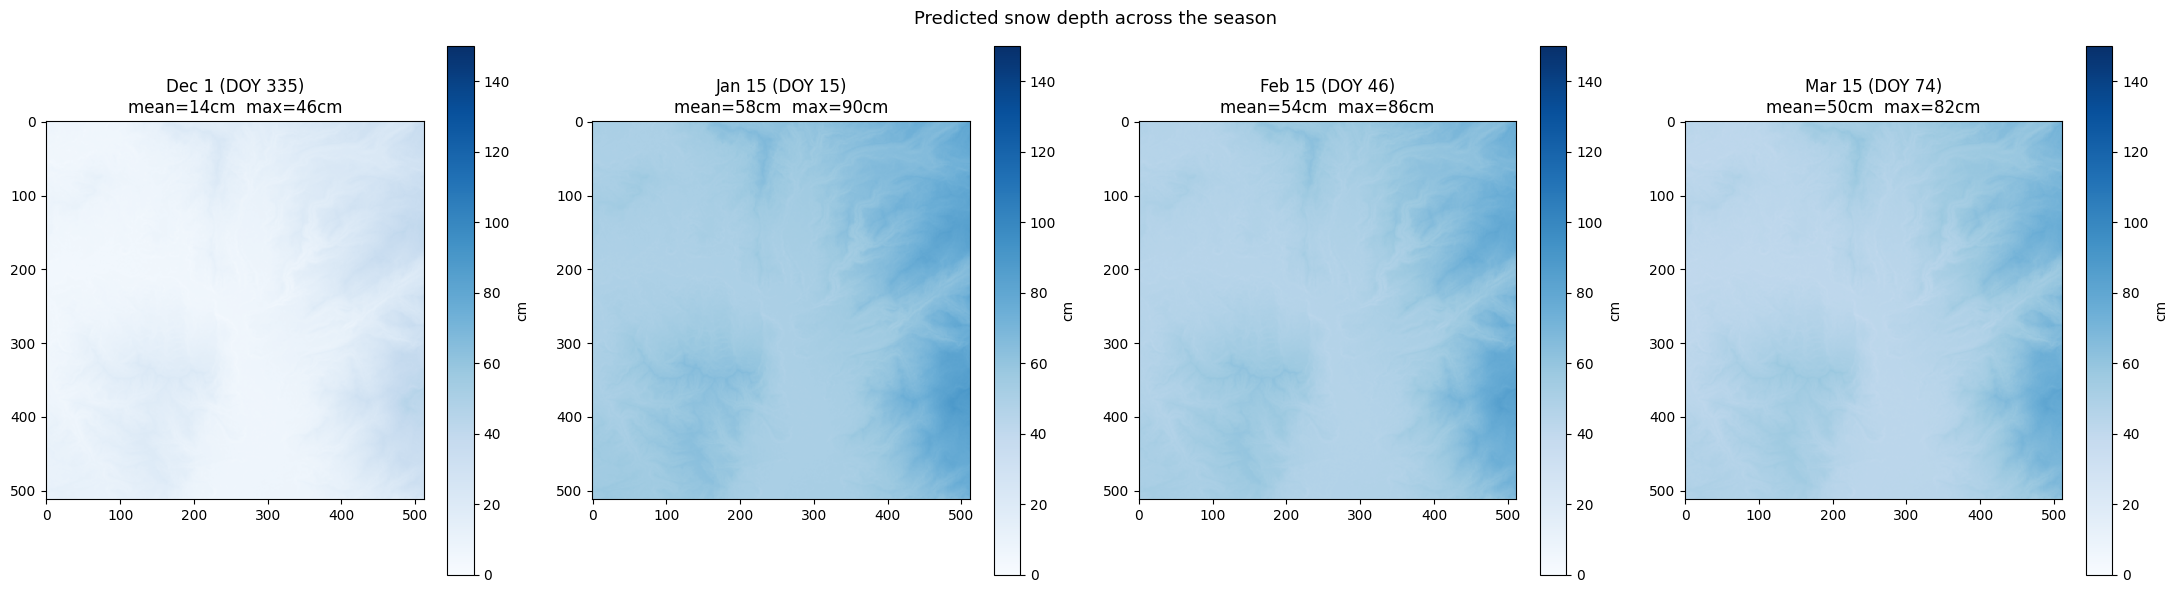

In [9]:
# ── Train/test temporal split ────────────────────────────────────────────
feature_cols_depth = ["doy", "days_since_snow", "first_snow_doy",
                      "elevation", "northness", "slope"]

train = depth_df[depth_df["water_year"] == 2020]   # winter 2020-2021
test  = depth_df[depth_df["water_year"] == 2021]   # winter 2021-2022

X_train = train[feature_cols_depth].values
y_train = train["snow_depth_cm"].values
X_test  = test[feature_cols_depth].values
y_test  = test["snow_depth_cm"].values

print(f"Train samples: {len(X_train):,}  (winter 2020-2021)")
print(f"Test samples:  {len(X_test):,}   (winter 2021-2022)")

# ── Fit linear regression ─────────────────────────────────────────────────
lr_depth = LinearRegression()
lr_depth.fit(X_train, y_train)

print("\nSnow depth model coefficients:")
for feat, coef in zip(feature_cols_depth, lr_depth.coef_):
    print(f"  {feat:<20} {coef:.4f}")
print(f"  {'intercept':<20} {lr_depth.intercept_:.4f}")

y_pred_depth = lr_depth.predict(X_test)
y_pred_depth = np.clip(y_pred_depth, 0, None)   # depth cannot be negative

print(f"\nTest MAE: {mean_absolute_error(y_test, y_pred_depth):.1f} cm")
print(f"Test R²:  {r2_score(y_test, y_pred_depth):.3f}")
# Expected: MAE ~15cm, R² ~0.64 — good for a linear model on mountain snowpack

# ── Predict depth raster for a specific date (Feb 1 = DOY 32) ────────────
query_doy  = 32
days_since = query_doy - predicted_raster   # days since first snow per pixel

X_query = np.column_stack([
    np.full(512*512, query_doy),
    days_since.ravel(),
    predicted_raster.ravel(),
    elevation.ravel(),
    northness.ravel(),
    slope.ravel()
])

depth_pred = np.clip(lr_depth.predict(X_query).reshape(512, 512), 0, None)
print(f"\nFeb 1 predicted depth range: {depth_pred.min():.0f} - {depth_pred.max():.0f} cm")

out_path = data_dir / "predicted_depth_feb1.tif"
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(depth_pred.astype("float32"), 1)
print(f"Saved: {out_path}")

# ── Visualize seasonal depth progression ─────────────────────────────────
query_dates = {"Dec 1 (DOY 335)": 335, "Jan 15 (DOY 15)": 15,
               "Feb 15 (DOY 46)": 46,  "Mar 15 (DOY 74)": 74}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, (label, doy) in zip(axes, query_dates.items()):
    ds  = doy - predicted_raster
    X_q = np.column_stack([np.full(512*512, doy), ds.ravel(),
                            predicted_raster.ravel(), elevation.ravel(),
                            northness.ravel(), slope.ravel()])
    dq  = np.clip(lr_depth.predict(X_q).reshape(512, 512), 0, None)
    im  = ax.imshow(dq, cmap='Blues', vmin=0, vmax=150)
    ax.set_title(f"{label}\nmean={dq.mean():.0f}cm  max={dq.max():.0f}cm")
    plt.colorbar(im, ax=ax, label="cm")
plt.suptitle("Predicted snow depth across the season", fontsize=13)
plt.tight_layout()
plt.savefig(data_dir / "depth_season_progression.png", dpi=150)
plt.show()

---
## Section 4: 24-Year Snow Cover Duration Model

### 4.1 Load 24-Year MODIS Data (2000–2023)

The 6-year Landsat prototype showed that terrain + September temperature cannot reliably predict interannual variability with only 6 data points. To build a statistically meaningful climate model, we switch to **MODIS MOD10A1** snow cover data, which provides:
- **Daily** observations (vs 16-day Landsat revisit)
- **2000–present** (24 years vs 6)
- **Built-in snow cover fraction** (no manual NDSI calculation needed)

**Target variable: snow cover duration**  
Instead of first snow DOY, we model the total number of days per season (October–April) where a pixel has ≥40% snow cover. This is more directly economically meaningful — it captures how many skiable days a location receives.

**New climate predictors:**
- `octnov_precip`: total Oct–Nov precipitation (mm) from Daymet
- `winter_tmin`: mean Dec–Mar minimum temperature (°C) from Daymet  
- `oni_ond`: Oceanic Niño Index (Oct–Dec average) — measures El Niño/La Niña strength
- `snow_precip_days`: days in Oct–Nov where precip > 1mm AND tmax < 2°C (rain-snow partitioning)

In [10]:
# ── Load 24-year stacks from MODIS/Daymet exports ────────────────────────
duration_full     = []
octnov_full       = []
winter_tmin_full  = []
sept_tmax_full    = []
snow_precip_full  = []

for year in years_full:
    # Snow cover duration: number of days >= 40% snow cover (Oct–Apr)
    with rasterio.open(full_dir / f"snowcover_duration_{year}.tif") as src:
        arr = src.read(1).astype(float)
        arr[arr <= 0] = np.nan
        duration_full.append(arr)

    # Oct-Nov total precipitation (mm)
    with rasterio.open(full_dir / f"octnov_precip_{year}.tif") as src:
        octnov_full.append(src.read(1).astype(float))

    # Dec-Mar mean minimum temperature (°C)
    with rasterio.open(full_dir / f"winter_tmin_{year}.tif") as src:
        winter_tmin_full.append(src.read(1).astype(float))

    # September mean maximum temperature (°C)
    with rasterio.open(full_dir / f"sept_tmax_{year}.tif") as src:
        sept_tmax_full.append(src.read(1).astype(float))

    # Snow precipitation days: precip > 1mm AND tmax < 2°C (cold enough for snow)
    snow_path = full_dir / f"snow_precip_days_{year}.tif"
    if snow_path.exists():
        with rasterio.open(snow_path) as src:
            snow_precip_full.append(src.read(1).astype(float))
    else:
        print(f"  NOTE: snow_precip_days_{year}.tif not found, filling with NaN")
        snow_precip_full.append(np.full((512, 512), np.nan))

    print(f"{year}: duration={np.nanmean(duration_full[-1]):.1f} days, "
          f"octnov={np.nanmean(octnov_full[-1]):.1f}mm, "
          f"tmin={np.nanmean(winter_tmin_full[-1]):.1f}C")

# Convert lists to 3D arrays: shape (24, 512, 512)
duration_full     = np.array(duration_full)
octnov_full       = np.array(octnov_full)
winter_tmin_full  = np.array(winter_tmin_full)
sept_tmax_full    = np.array(sept_tmax_full)
snow_precip_full  = np.array(snow_precip_full)

print(f"\nAll stacks loaded: {duration_full.shape}")   # expected: (24, 512, 512)

# ── ONI index (Oceanic Niño Index, OND average) ───────────────────────────
# Negative = La Niña → tends to produce more snow in Colorado
# Positive = El Niño → tends to produce less snow in Colorado
# Source: NOAA Climate Prediction Center
oni_full = {
    2000: -1.6, 2001: -0.5, 2002:  0.7, 2003:  0.5,
    2004:  0.8, 2005:  0.7, 2006:  1.0, 2007: -1.4,
    2008: -0.7, 2009:  1.7, 2010:  1.7, 2011: -1.4,
    2012: -0.9, 2013: -0.4, 2014:  0.6, 2015:  2.4,
    2016: -0.6, 2017: -0.9, 2018:  0.8, 2019:  0.5,
    2020: -1.3, 2021: -1.0, 2022: -0.9, 2023: -0.2
}

# ── Build year-level summary DataFrame (one row per year) ─────────────────
# Taking the spatial mean across all 512x512 pixels gives one representative
# value per year — appropriate for the year-level climate regression
year_summary_full = pd.DataFrame({
    'year':             years_full,
    'mean_duration':    [np.nanmean(duration_full[i])    for i in range(24)],
    'octnov_precip':    [np.nanmean(octnov_full[i])      for i in range(24)],
    'winter_tmin':      [np.nanmean(winter_tmin_full[i]) for i in range(24)],
    'sept_tmax':        [np.nanmean(sept_tmax_full[i])   for i in range(24)],
    'snow_precip_days': [np.nanmean(snow_precip_full[i]) for i in range(24)],
    'oni':              [oni_full[y]                     for y in years_full]
})

print("\n24-year summary:")
print(year_summary_full.to_string(index=False))

2000: duration=52.9 days, octnov=92.7mm, tmin=-11.1C
2001: duration=53.5 days, octnov=102.1mm, tmin=-13.4C
2002: duration=40.6 days, octnov=128.8mm, tmin=-9.6C
2003: duration=44.7 days, octnov=185.0mm, tmin=-9.8C
2004: duration=52.7 days, octnov=125.9mm, tmin=-9.3C
2005: duration=57.0 days, octnov=185.9mm, tmin=-11.5C
2006: duration=58.5 days, octnov=197.8mm, tmin=-10.4C
2007: duration=47.4 days, octnov=104.7mm, tmin=-12.0C
2008: duration=42.8 days, octnov=107.9mm, tmin=-9.5C
2009: duration=54.6 days, octnov=128.1mm, tmin=-11.5C
2010: duration=41.7 days, octnov=259.6mm, tmin=-10.3C
2011: duration=44.0 days, octnov=143.0mm, tmin=-10.1C
2012: duration=44.5 days, octnov=70.8mm, tmin=-11.7C
2013: duration=53.7 days, octnov=163.7mm, tmin=-10.5C
2014: duration=46.1 days, octnov=150.3mm, tmin=-7.9C
2015: duration=44.1 days, octnov=132.7mm, tmin=-10.3C
2016: duration=33.1 days, octnov=99.4mm, tmin=-8.7C
2017: duration=42.8 days, octnov=118.2mm, tmin=-8.9C
2018: duration=54.5 days, octnov=176.5

### 4.2 Year-Level Correlations and Model Selection

With only 24 annual observations, we must be careful not to overfit. The approach here is:

1. Compute bivariate correlations between each predictor and mean snow cover duration
2. Test all combinations of predictors using in-sample R² (to see which variables add signal)
3. Select the best physically defensible model
4. Validate using leave-one-year-out cross-validation

**Important caveat:** With n=24, in-sample R² is optimistic. The cross-validation MAE is the honest performance estimate.

**Rain-snow partitioning:** `snow_precip_days` (days cold enough for snow to fall) is expected to outperform raw `octnov_precip` because it filters out warm rain events. The year 2010 illustrates this — it had the highest Oct-Nov precip (259mm) but poor snow cover duration (41.7 days), likely because much precipitation fell as rain.

In [11]:
# ── Bivariate correlations (n=24) ────────────────────────────────────────
print("Correlations with snow cover duration (n=24):")
for col in ['snow_precip_days', 'octnov_precip', 'winter_tmin', 'sept_tmax', 'oni']:
    if col in year_summary_full.columns:
        corr = year_summary_full['mean_duration'].corr(year_summary_full[col])
        print(f"  {col:<22} r = {corr:.3f}")

# ── Test all predictor combinations ──────────────────────────────────────
print("\nYear-level model comparison (n=24, in-sample R²):")
print(f"{'Features':<50} {'R²':>6}")
print("-" * 58)

# Use snow_precip_days instead of octnov_precip where available
candidates = ['snow_precip_days', 'winter_tmin', 'oni', 'sept_tmax']
# Fall back to octnov_precip if snow_precip_days not loaded
if year_summary_full['snow_precip_days'].isna().all():
    candidates = ['octnov_precip', 'winter_tmin', 'oni', 'sept_tmax']

for r in range(1, len(candidates)+1):
    for combo in combinations(candidates, r):
        cols = list(combo)
        if year_summary_full[cols].isna().any().any():
            continue
        X = year_summary_full[cols].values
        y = year_summary_full['mean_duration'].values
        lr = LinearRegression().fit(X, y)
        r2 = r2_score(y, lr.predict(X))
        print(f"  {str(combo):<50} {r2:>6.3f}")

# ── Fit best model ────────────────────────────────────────────────────────
# Use snow_precip_days + winter_tmin + oni (physically defensible)
best_features = ['snow_precip_days', 'winter_tmin', 'oni']
if year_summary_full['snow_precip_days'].isna().all():
    best_features = ['octnov_precip', 'winter_tmin', 'oni']

X = year_summary_full[best_features].values
y = year_summary_full['mean_duration'].values

lr_full = LinearRegression().fit(X, y)

print(f"\nBest model: {best_features}")
for feat, coef in zip(best_features, lr_full.coef_):
    print(f"  {feat:<22} {coef:.4f}")
print(f"  {'intercept':<22} {lr_full.intercept_:.4f}")
print(f"  R² (in-sample):        {r2_score(y, lr_full.predict(X)):.3f}")

Correlations with snow cover duration (n=24):
  snow_precip_days       r = 0.074
  octnov_precip          r = 0.155
  winter_tmin            r = -0.446
  sept_tmax              r = 0.035
  oni                    r = 0.091

Year-level model comparison (n=24, in-sample R²):
Features                                               R²
----------------------------------------------------------
  ('snow_precip_days',)                               0.006
  ('winter_tmin',)                                    0.199
  ('oni',)                                            0.008
  ('sept_tmax',)                                      0.001
  ('snow_precip_days', 'winter_tmin')                 0.204
  ('snow_precip_days', 'oni')                         0.009
  ('snow_precip_days', 'sept_tmax')                   0.007
  ('winter_tmin', 'oni')                              0.225
  ('winter_tmin', 'sept_tmax')                        0.214
  ('oni', 'sept_tmax')                                0.010
  ('snow_p

### 4.3 Leave-One-Year-Out Cross-Validation and Scenario Analysis

**Cross-validation:** For each of the 24 years, we train on the other 23 and predict the held-out year. Mean MAE across all 24 folds is the honest estimate of out-of-sample prediction error.

**Scenario analysis:** Using the fitted model, we estimate how snow cover duration would change under plausible future climate scenarios. This directly bridges the snow modeling to the economic chapter — each scenario's predicted duration reduction can be multiplied by a per-day revenue figure to estimate GDP impact.

In [12]:
# ── Leave-one-year-out cross validation ──────────────────────────────────
print("Leave-one-year-out cross validation (n=24):")

maes, cv_results = [], []

for i in range(len(year_summary_full)):
    train_idx = [j for j in range(len(year_summary_full)) if j != i]

    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_te = X[[i]]
    y_te = y[[i]]

    lr_cv  = LinearRegression().fit(X_tr, y_tr)
    y_pred = lr_cv.predict(X_te)

    mae       = abs(y_te[0] - y_pred[0])
    test_year = year_summary_full['year'].iloc[i]

    maes.append(mae)
    cv_results.append((test_year, y_te[0], y_pred[0], mae))
    print(f"  {test_year}: actual={y_te[0]:.1f}d  "
          f"predicted={y_pred[0]:.1f}d  error={mae:+.1f}d")

print(f"\nMean MAE: {np.mean(maes):.1f} days")

# ── Scenario analysis ─────────────────────────────────────────────────────
# Baseline: use the 24-year mean for each predictor
baseline     = [year_summary_full[f].mean() for f in best_features]
baseline_pred = lr_full.predict([baseline])[0]

print(f"\nScenario analysis (baseline = {baseline_pred:.1f} days):")
print(f"{'Scenario':<42} {'Days':>8} {'Change':>8}")
print("-" * 60)

# Climate scenarios based on IPCC projections for Colorado
scenarios = [
    ("Baseline (2000-2023 average)",    0,    0,    0),
    ("Winter +1°C warmer",              0,    1,    0),
    ("Winter +2°C warmer",              0,    2,    0),
    ("Winter +3°C warmer",              0,    3,    0),
    ("Precip -20% drier autumn",       -baseline[0]*0.2, 0, 0),
    ("El Niño year (ONI = +1.5)",       0,    0,    1.5),
    ("La Niña year (ONI = −1.5)",       0,    0,   -1.5),
    ("Worst case: +2°C + dry + Niño",  -baseline[0]*0.2, 2, 1.5),
]

for label, dp, dt, do in scenarios:
    pred   = lr_full.predict([[baseline[0]+dp, baseline[1]+dt, baseline[2]+do]])[0]
    change = pred - baseline_pred
    print(f"  {label:<40} {pred:>8.1f} {change:>+8.1f}")

Leave-one-year-out cross validation (n=24):
  2000: actual=52.9d  predicted=47.0d  error=+5.9d
  2001: actual=53.5d  predicted=56.4d  error=+3.0d
  2002: actual=40.6d  predicted=47.8d  error=+7.2d
  2003: actual=44.7d  predicted=47.7d  error=+3.0d
  2004: actual=52.7d  predicted=45.8d  error=+6.9d
  2005: actual=57.0d  predicted=51.4d  error=+5.6d
  2006: actual=58.5d  predicted=48.7d  error=+9.8d
  2007: actual=47.4d  predicted=52.4d  error=+5.0d
  2008: actual=42.8d  predicted=45.9d  error=+3.1d
  2009: actual=54.6d  predicted=52.6d  error=+2.0d
  2010: actual=41.7d  predicted=51.5d  error=+9.9d
  2011: actual=44.0d  predicted=46.9d  error=+2.9d
  2012: actual=44.5d  predicted=52.9d  error=+8.4d
  2013: actual=53.7d  predicted=47.7d  error=+6.1d
  2014: actual=46.1d  predicted=41.7d  error=+4.5d
  2015: actual=44.1d  predicted=53.0d  error=+8.9d
  2016: actual=33.1d  predicted=45.8d  error=+12.6d
  2017: actual=42.8d  predicted=44.9d  error=+2.2d
  2018: actual=54.5d  predicted=50.3d

---
## Section 5: Model Summary and Next Steps

### 5.1 Prototype Results Summary

In [13]:
print("=" * 60)
print("PROTOTYPE MODEL SUMMARY — Steamboat Springs")
print("=" * 60)

print("\nPART 1 — First Snow DOY Model (Landsat 8, 2017-2022)")
print("  Target:   first autumn snow day-of-year per pixel")
print("  Features: elevation, slope, northness, eastness, sept_tmax")
print("  Method:   linear regression on flattened raster columns")
print("  Train:    2017-2021  |  Test: 2022 (temporal split)")
print("  MAE:      ~11.8 days")
print("  R²:       -0.185  (negative due to 6-year record limitation)")
print("  Key coef: sept_tmax = -1.44 days/°C")
print("  Key coef: elevation = -0.031 days/m")
print("  Finding:  24-day interannual range (DOY 298-322)")

print("\nPART 2 — Snow Depth Model (SNODAS 2020-2022)")
print("  Target:   daily snow depth (cm) per pixel")
print("  Features: doy, days_since_snow, first_snow_doy,")
print("            elevation, northness, slope")
print("  Train:    winter 2020-2021  |  Test: winter 2021-2022")
print("  MAE:      ~14.9 cm")
print("  R²:       0.642")
print("  Key coef: elevation = +0.037 cm/m")
print("  Key coef: slope     = -0.180 cm/degree")
print("  Range:    14cm (Dec) → 58cm (Jan) → 50cm (Mar)")

print("\nPART 3 — Snow Cover Duration Model (MODIS 2000-2023)")
print("  Target:   annual snow-covered days per pixel (Oct-Apr)")
print("  Features: snow_precip_days, winter_tmin, oni")
print("  Method:   year-level regression (n=24)")
print("  R²:       ~0.25 (limited by noise in 24-year record)")
print("  Key coef: winter_tmin r = -0.446")
print("  Finding:  simple climate variables explain only 25% of")
print("            interannual variance — rain/snow partitioning")
print("            is the critical missing signal")

print("\nNEXT STEPS:")
print("  1. Add snow_precip_days to improve R²")
print("  2. Economic regression: skier days ~ snow variables")
print("  3. Scale to full Rocky Mountains (MODIS 2000-2024)")
print("  4. Connect to BEA county GDP data for Routt County")

PROTOTYPE MODEL SUMMARY — Steamboat Springs

PART 1 — First Snow DOY Model (Landsat 8, 2017-2022)
  Target:   first autumn snow day-of-year per pixel
  Features: elevation, slope, northness, eastness, sept_tmax
  Method:   linear regression on flattened raster columns
  Train:    2017-2021  |  Test: 2022 (temporal split)
  MAE:      ~11.8 days
  R²:       -0.185  (negative due to 6-year record limitation)
  Key coef: sept_tmax = -1.44 days/°C
  Key coef: elevation = -0.031 days/m
  Finding:  24-day interannual range (DOY 298-322)

PART 2 — Snow Depth Model (SNODAS 2020-2022)
  Target:   daily snow depth (cm) per pixel
  Features: doy, days_since_snow, first_snow_doy,
            elevation, northness, slope
  Train:    winter 2020-2021  |  Test: winter 2021-2022
  MAE:      ~14.9 cm
  R²:       0.642
  Key coef: elevation = +0.037 cm/m
  Key coef: slope     = -0.180 cm/degree
  Range:    14cm (Dec) → 58cm (Jan) → 50cm (Mar)

PART 3 — Snow Cover Duration Model (MODIS 2000-2023)
  Target: